In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-dataset


In [3]:
# Standard libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

# Deep Learning libraries (PyTorch)
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check if GPU is enabled (Should output 'cuda:0' for your T4)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download dataset using Kagglehub (from your screenshot)
print("Downloading dataset...")
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print(f"Path to dataset files: {path}")

# Note: The Kaggle dataset structure might have a subfolder.
# We need the path that directly contains the 10 class folders (Forest, Highway, etc.)
# Usually it's in a subfolder named 'EuroSAT' or directly in the 'path'.
data_dir = path
if os.path.exists(os.path.join(path, 'EuroSAT')):
    data_dir = os.path.join(path, 'EuroSAT')

Using device: cuda:0
Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-dataset


In [4]:
# ImageNet statistics required for VGG16 transfer learning
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
input_size = 224 # VGG16 expected input size

# Training transforms with Augmentation (Resizing, Flips, Normalization)
train_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Validation/Testing transforms (No Augmentation, only Resizing and Normalization)
val_test_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [5]:
# Load the full dataset (We will apply specific transforms to the splits later)
# For now, we load it just to get the sizes and classes
full_dataset = datasets.ImageFolder(data_dir)
class_names = full_dataset.classes
print(f"Classes found: {class_names}")
print(f"Total images: {len(full_dataset)}")

# Calculate split sizes (70% Train, 15% Val, 15% Test)
train_size = 0.70
val_size = 0.15

indices = list(range(len(full_dataset)))
np.random.shuffle(indices) # Shuffle data before splitting

train_split = int(train_size * len(full_dataset))
val_split = int(val_size * len(full_dataset))

train_indices = indices[:train_split]
val_indices = indices[train_split : train_split + val_split]
test_indices = indices[train_split + val_split:]

print(f"Split sizes -> Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(test_indices)}")

Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
Split sizes -> Train: 18900 | Val: 4050 | Test: 4050


In [6]:
class EuroSATSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        # Extract image and label from the original dataset
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Apply subsets and transforms
train_data = EuroSATSubset(Subset(full_dataset, train_indices), transform=train_transform)
val_data = EuroSATSubset(Subset(full_dataset, val_indices), transform=val_test_transform)
test_data = EuroSATSubset(Subset(full_dataset, test_indices), transform=val_test_transform)

# Create DataLoaders
batch_size = 64 # Fits easily on a 15GB T4 GPU
num_workers = 2

train_loader = DataLoader(train_data, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, num_workers=num_workers, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=num_workers, shuffle=False)

print("DataLoaders successfully created!")

DataLoaders successfully created!


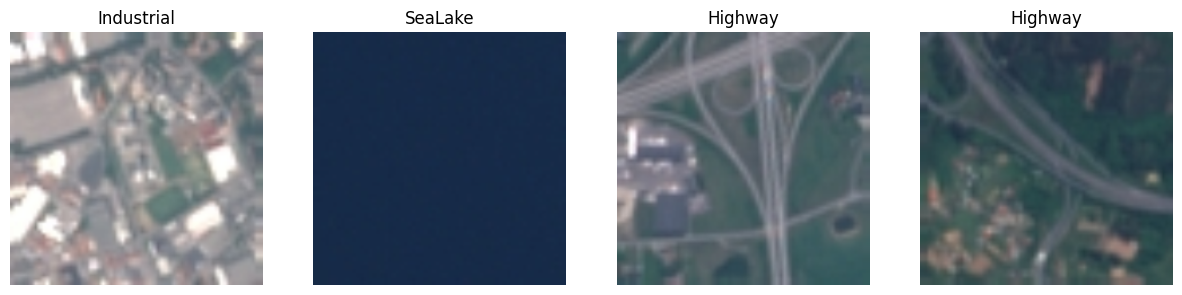

In [7]:
# Fetch a batch of training data
inputs, classes = next(iter(train_loader))

# Visualize 4 images
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    # Un-normalize the image for visualization
    image = inputs[i].numpy().transpose((1, 2, 0))
    image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

    title = class_names[classes[i]]
    axes[i].imshow(image)
    axes[i].set_title(title)
    axes[i].axis('off')
plt.show()

In [8]:
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

# 1. Load the pre-trained VGG16 model
model = vgg16(weights=VGG16_Weights.DEFAULT)

# 2. Freeze the convolutional base (feature extractor)
for param in model.features.parameters():
    param.requires_grad = False

# 3. Replace the classifier
# VGG16's features output is 512 channels * 7x7 spatial size = 25088
# We use a structure similar to the paper: FC(256) -> Dropout -> FC(10)
num_features = model.classifier[0].in_features # This is 25088

model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5), # 50% dropout to prevent overfitting
    nn.Linear(256, len(class_names)) # Output 10 classes
)

# Move model to the GPU
model = model.to(device)

print("VGG16 successfully loaded and modified!")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 70.4MB/s]


VGG16 successfully loaded and modified!


In [11]:
import torch.optim as optim

# Loss function: Cross Entropy (PyTorch applies Softmax internally)
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam (Only train the classifier parameters, since features are frozen)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Scheduler: Reduce learning rate by half (factor=0.5) if validation loss plateaus for 3 epochs
# (Removed 'verbose=True' for compatibility with newer PyTorch versions)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [12]:
import copy
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25, patience=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Update scheduler and Early Stopping based on validation loss
            if phase == 'val':
                scheduler.step(epoch_loss)

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs.')
            break
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Loss: {best_val_loss:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Start Training! (This will take a little while on the T4 GPU)
trained_model, training_history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25, patience=5
)

Epoch 1/25
----------
Train Loss: 0.3530 Acc: 0.8815
Val Loss: 0.1820 Acc: 0.9383

Epoch 2/25
----------
Train Loss: 0.2293 Acc: 0.9251
Val Loss: 0.1890 Acc: 0.9365

Epoch 3/25
----------
Train Loss: 0.1918 Acc: 0.9371
Val Loss: 0.1723 Acc: 0.9452

Epoch 4/25
----------
Train Loss: 0.1706 Acc: 0.9438
Val Loss: 0.1694 Acc: 0.9444

Epoch 5/25
----------
Train Loss: 0.1547 Acc: 0.9488
Val Loss: 0.1650 Acc: 0.9472

Epoch 6/25
----------
Train Loss: 0.1449 Acc: 0.9537
Val Loss: 0.1668 Acc: 0.9484

Epoch 7/25
----------
Train Loss: 0.1372 Acc: 0.9540
Val Loss: 0.1630 Acc: 0.9467

Epoch 8/25
----------
Train Loss: 0.1278 Acc: 0.9593
Val Loss: 0.1667 Acc: 0.9491

Epoch 9/25
----------
Train Loss: 0.1098 Acc: 0.9643
Val Loss: 0.1563 Acc: 0.9526

Epoch 10/25
----------
Train Loss: 0.1185 Acc: 0.9615
Val Loss: 0.1654 Acc: 0.9467

Epoch 11/25
----------
Train Loss: 0.1045 Acc: 0.9681
Val Loss: 0.1664 Acc: 0.9491

Epoch 12/25
----------
Train Loss: 0.1005 Acc: 0.9671
Val Loss: 0.1869 Acc: 0.9457

E

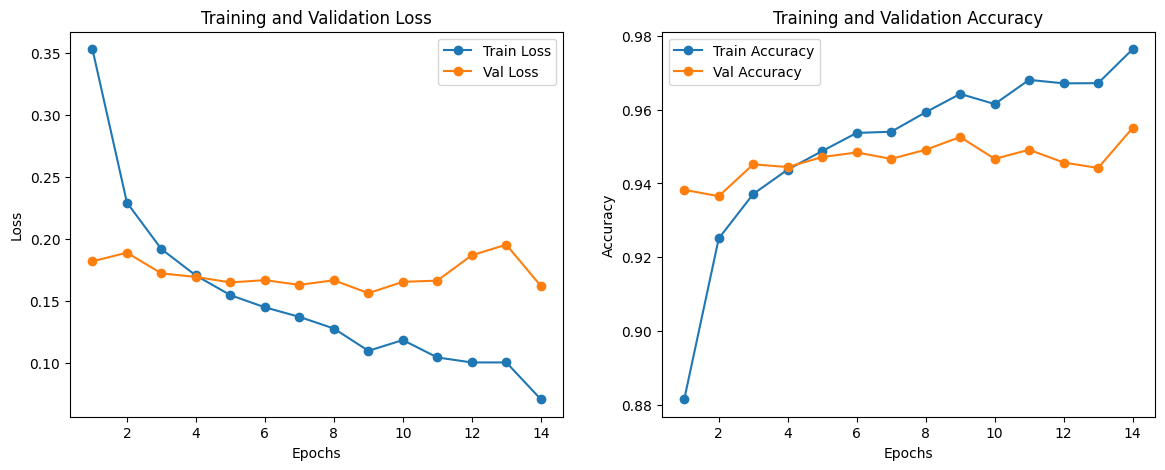

In [13]:
import matplotlib.pyplot as plt

# Extract data from history
train_loss = training_history['train_loss']
val_loss = training_history['val_loss']
train_acc = training_history['train_acc']
val_acc = training_history['val_acc']
epochs_range = range(1, len(train_loss) + 1)

# Plot Loss and Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_loss, label='Train Loss', marker='o')
ax1.plot(epochs_range, val_loss, label='Val Loss', marker='o')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, train_acc, label='Train Accuracy', marker='o')
ax2.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

In [14]:
# Set model to evaluation mode
trained_model.eval()

all_preds = []
all_labels = []
test_running_corrects = 0

print("Evaluating on Test Set...")

# Disable gradient calculation for testing (saves memory and speeds up computation)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = trained_model(inputs)
        _, preds = torch.max(outputs, 1)

        test_running_corrects += torch.sum(preds == labels.data)

        # Store predictions and true labels for the confusion matrix
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_running_corrects.double() / len(test_loader.dataset)
print(f'Final Test Accuracy: {test_acc:.4f} ({(test_acc*100):.2f}%)')

Evaluating on Test Set...
Final Test Accuracy: 0.9489 (94.89%)



Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.93      0.95       439
              Forest       0.97      0.99      0.98       447
HerbaceousVegetation       0.95      0.96      0.96       436
             Highway       0.90      0.90      0.90       374
          Industrial       0.97      0.96      0.96       380
             Pasture       0.93      0.88      0.91       268
       PermanentCrop       0.90      0.95      0.92       382
         Residential       0.97      0.99      0.98       430
               River       0.93      0.91      0.92       420
             SeaLake       0.99      0.99      0.99       474

            accuracy                           0.95      4050
           macro avg       0.95      0.95      0.95      4050
        weighted avg       0.95      0.95      0.95      4050



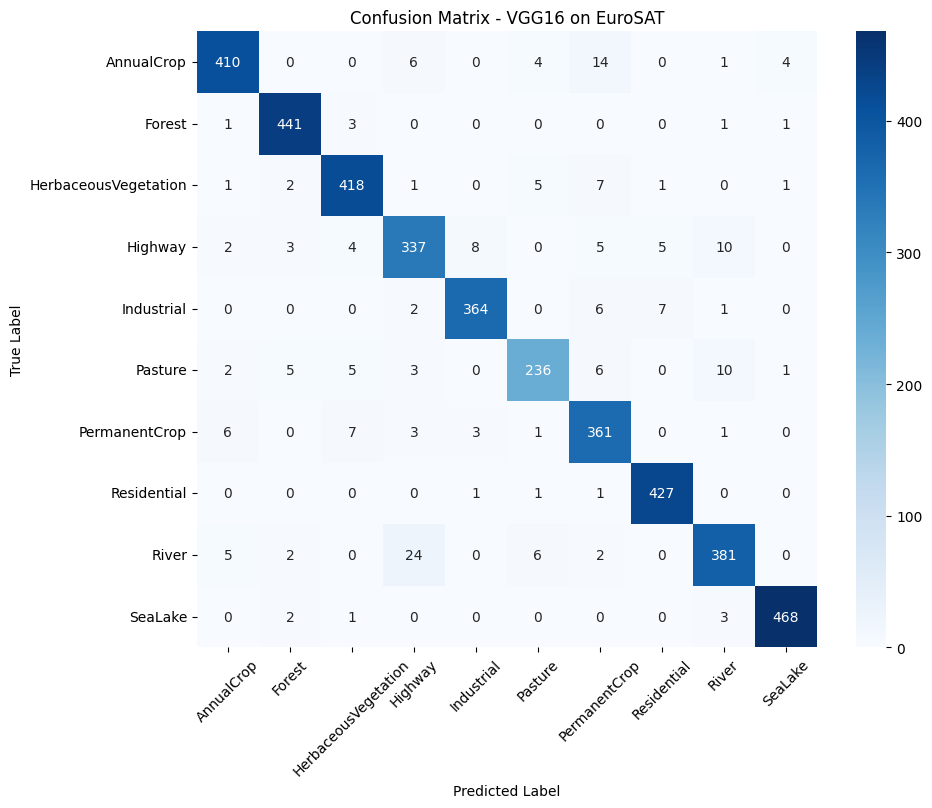

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Print Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - VGG16 on EuroSAT')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.show()

In [16]:
import torch.nn as nn
from torchvision import models

def get_pretrained_model(model_name, num_classes=10):
    print(f"Loading {model_name}...")

    if model_name == 'vgg19':
        model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        # Freeze features
        for param in model.features.parameters():
            param.requires_grad = False
        # Replace classifier
        num_ftrs = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    elif model_name in ['resnet50', 'resnet152', 'wide_resnet50_2']:
        if model_name == 'resnet50':
            model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        elif model_name == 'resnet152':
            model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
        elif model_name == 'wide_resnet50_2':
            model = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.DEFAULT)

        # Freeze features
        for param in model.parameters():
            param.requires_grad = False

        # Replace classifier (ResNet uses 'fc' instead of 'classifier')
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        # Unfreeze the new fc layer
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == 'efficientnet_v2_s':
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        # Freeze features
        for param in model.features.parameters():
            param.requires_grad = False

        # Replace classifier
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(num_ftrs, num_classes)
        )

    else:
        raise ValueError("Model name not recognized.")

    model = model.to(device)
    return model

In [17]:
import torch.optim as optim

# --- CHOOSE YOUR MODEL HERE ---
# Options: 'vgg19', 'resnet50', 'resnet152', 'wide_resnet50_2', 'efficientnet_v2_s'
CURRENT_MODEL_NAME = 'resnet50'
# ------------------------------

# 1. Load the specific model
model = get_pretrained_model(CURRENT_MODEL_NAME, num_classes=len(class_names))

# 2. Setup Loss, Optimizer, and Scheduler
criterion = nn.CrossEntropyLoss()

# We only want to pass the parameters that require gradients (the un-frozen ones) to the optimizer
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=0.001)

# Scheduler (Removed verbose=True based on our previous fix)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 3. Train the model (using the train_model function we defined earlier)
print(f"\n--- Starting Training for {CURRENT_MODEL_NAME} ---")
trained_model, training_history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25, patience=5
)

# 4. Evaluate on Test Set
trained_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = trained_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 5. Print Final Results
from sklearn.metrics import classification_report
print(f"\n--- Final Results for {CURRENT_MODEL_NAME} ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

Loading resnet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]



--- Starting Training for resnet50 ---
Epoch 1/25
----------
Train Loss: 0.6020 Acc: 0.8073
Val Loss: 0.2670 Acc: 0.9131

Epoch 2/25
----------
Train Loss: 0.3109 Acc: 0.8977
Val Loss: 0.2017 Acc: 0.9343

Epoch 3/25
----------
Train Loss: 0.2568 Acc: 0.9106
Val Loss: 0.1903 Acc: 0.9370

Epoch 4/25
----------
Train Loss: 0.2342 Acc: 0.9208
Val Loss: 0.1934 Acc: 0.9321

Epoch 5/25
----------
Train Loss: 0.2227 Acc: 0.9230
Val Loss: 0.1768 Acc: 0.9447

Epoch 6/25
----------
Train Loss: 0.2085 Acc: 0.9296
Val Loss: 0.1568 Acc: 0.9442

Epoch 7/25
----------
Train Loss: 0.2032 Acc: 0.9308
Val Loss: 0.1745 Acc: 0.9393

Epoch 8/25
----------
Train Loss: 0.1901 Acc: 0.9354
Val Loss: 0.1544 Acc: 0.9454

Epoch 9/25
----------
Train Loss: 0.1889 Acc: 0.9334
Val Loss: 0.1603 Acc: 0.9447

Epoch 10/25
----------
Train Loss: 0.1798 Acc: 0.9376
Val Loss: 0.1546 Acc: 0.9454

Epoch 11/25
----------
Train Loss: 0.1660 Acc: 0.9425
Val Loss: 0.1484 Acc: 0.9494

Epoch 12/25
----------
Train Loss: 0.1623 Acc

In [19]:
import os

# Create a directory to store the weights if it doesn't exist
weights_dir = 'model_weights'
os.makedirs(weights_dir, exist_ok=True)

# Save the weights for the current trained model (which is resnet50 based on the previous cell)
resnet_weight_path = os.path.join(weights_dir, f'{CURRENT_MODEL_NAME}_best_weights.pth')
torch.save(trained_model.state_dict(), resnet_weight_path)

print(f"Weights for {CURRENT_MODEL_NAME} saved to: {resnet_weight_path}")

Weights for resnet50 saved to: model_weights/resnet50_best_weights.pth


In [20]:
# Since we already trained VGG16 (stored in the 'trained_model' variable previously),
# we can save its weights. Note: if you re-ran the ResNet cell, 'trained_model'
# currently holds ResNet. I will provide a way to save VGG16 weights specifically.

vgg16_weight_path = os.path.join(weights_dir, 'vgg16_best_weights.pth')
# To ensure we save the right one, users would typically save immediately after training.
# If 'model' still holds the VGG16 architecture from the earlier cell:
torch.save(model.state_dict(), vgg16_weight_path)
print(f"Weights for VGG16 saved to: {vgg16_weight_path}")

Weights for VGG16 saved to: model_weights/vgg16_best_weights.pth


### Note on VGG16 Weights
Since we trained VGG16 earlier in the notebook and the `trained_model` variable was overwritten by ResNet50, we should save the VGG16 weights immediately after its training step if you plan to switch between models frequently.

I have added a general saving block above. To save any other model, simply ensure you call `torch.save(model.state_dict(), path)` after the `train_model` function returns.

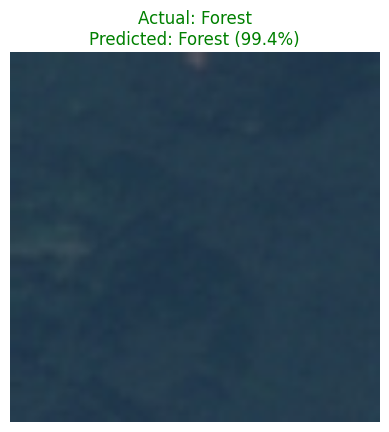

In [21]:
import torch.nn.functional as F

def predict_random_image(model, dataset, class_names):
    # 1. Pick a random image from the test set
    idx = np.random.randint(len(dataset))
    img_tensor, label = dataset[idx]

    # 2. Inference
    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        prob = F.softmax(output, dim=1)
        conf, pred = torch.max(prob, 1)

    # 3. Visualize
    image = img_tensor.numpy().transpose((1, 2, 0))
    image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

    plt.imshow(image)
    color = 'green' if pred.item() == label else 'red'
    plt.title(f"Actual: {class_names[label]}\nPredicted: {class_names[pred.item()]} ({conf.item()*100:.1f}%)", color=color)
    plt.axis('off')
    plt.show()

# Test the ResNet50 model we just finalized
predict_random_image(trained_model, test_data, class_names)

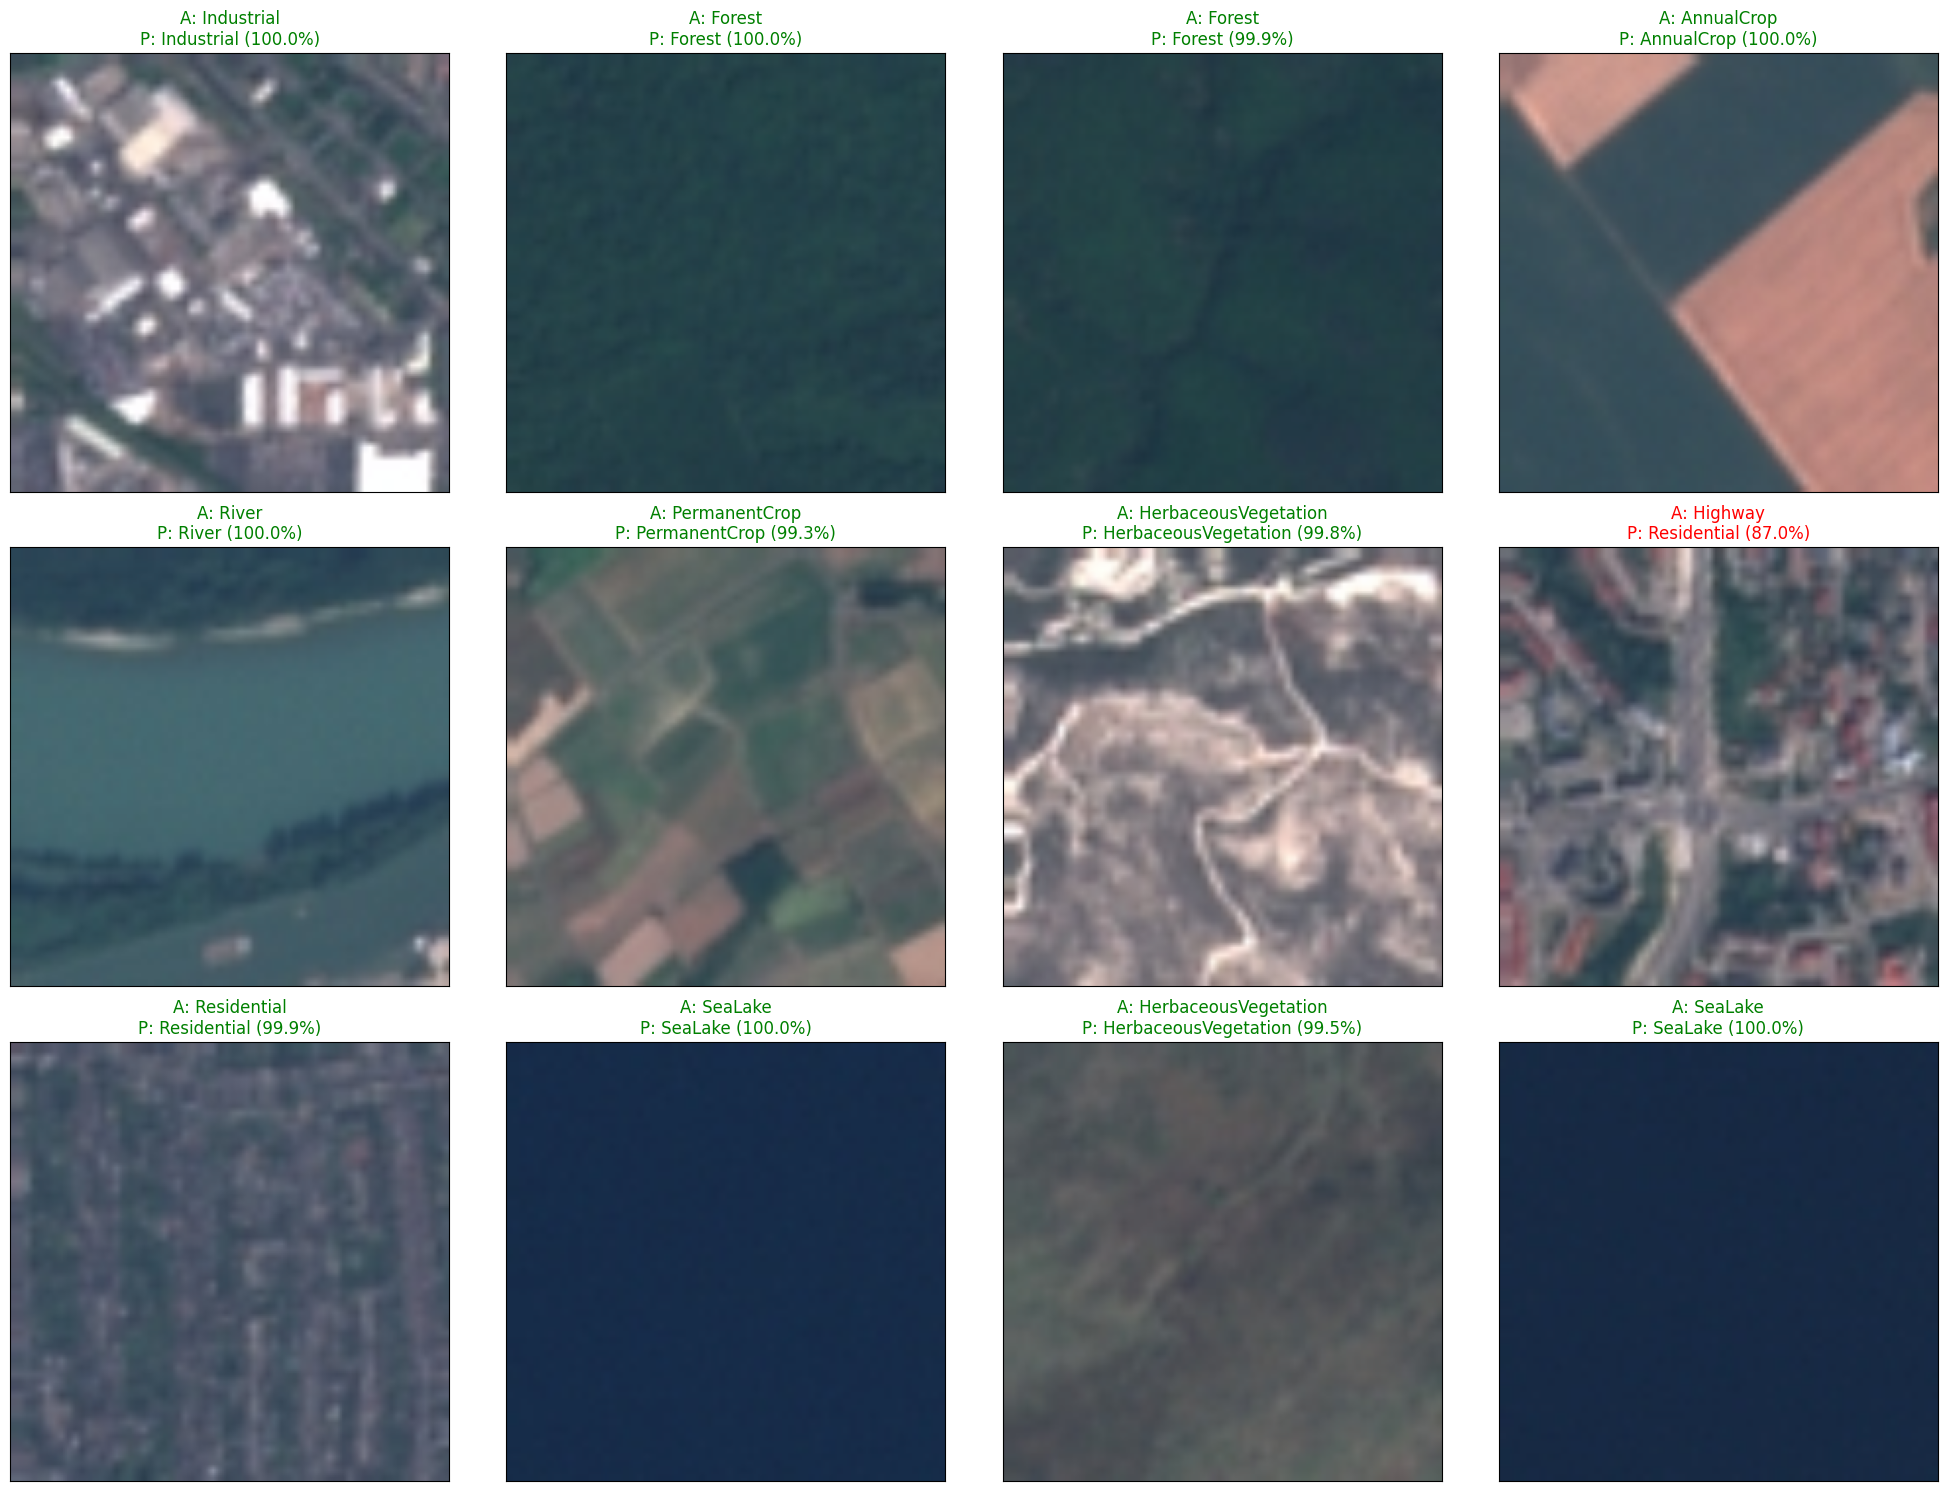

In [22]:
def visualize_model_predictions(model, dataset, class_names, num_images=12):
    model.eval()
    fig = plt.figure(figsize=(20, 15))

    # Pick random indices
    indices = np.random.choice(len(dataset), num_images, replace=False)

    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]

        # Inference
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))
            prob = F.softmax(output, dim=1)
            conf, pred = torch.max(prob, 1)

        # Process image for plotting
        image = img_tensor.numpy().transpose((1, 2, 0))
        image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

        ax = fig.add_subplot(3, 4, i + 1, xticks=[], yticks=[])
        plt.imshow(image)

        is_correct = pred.item() == label
        color = 'green' if is_correct else 'red'

        ax.set_title(f"A: {class_names[label]}\nP: {class_names[pred.item()]} ({conf.item()*100:.1f}%)",
                     color=color, fontsize=12)

    plt.tight_layout()
    plt.show()

# Visualize 12 random predictions from the test set using the ResNet50 model
visualize_model_predictions(trained_model, test_data, class_names, num_images=12)